# Mapping

In [1]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

# if notebook is in notebooks/, go up one level
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [2]:
import pandas as pd

In [3]:
data = pd.read_pickle(DATA/'ml_datasets/all_raw_samples.pkl')

In [4]:
features = pd.read_pickle(DATA/'ml_datasets/L2_DATASET_mapping.pkl')


target_cols =  ['EX_o2_e','EX_glc__D_e', 'EX_ac_e', 'EX_lcts_e', 'EX_glyc_e', 'EX_arg__L_e', 'EX_nh4_e', 'EX_no3_e']
target = data[target_cols]

In [15]:
pd.read_pickle(DATA/'(active_bm_rxns_1.pkl)')

,reaction,biomass_type,glc_sample_0,glc_sample_1,glc_sample_2,glc_sample_3,glc_sample_4,glc_sample_5,glc_sample_6,glc_sample_7,...,no3_glyc_sample_588,no3_glyc_sample_589,no3_glyc_sample_590,no3_glyc_sample_591,no3_glyc_sample_592,no3_glyc_sample_593,no3_glyc_sample_594,no3_glyc_sample_595,variance,corr_with_mu
13,transcription_TU0_14486_from_RpoD_mono_rRNA,rRNA,7.492656e-07,4.139004e-06,1.564352e-06,8.850734e-07,0.000000e+00,5.739838e-06,9.583766e-07,5.072240e-06,...,1.661425e-06,7.851360e-06,2.218893e-06,1.358170e-06,0.000000e+00,6.422142e-07,7.199528e-07,4.853930e-06,1.775572e-11,0.969532
28,transcription_TU0_1190_from_RpoD_mono_rRNA,rRNA,1.162242e-06,6.843194e-06,2.865682e-06,1.651963e-06,3.946777e-07,9.277584e-06,1.512909e-06,0.000000e+00,...,3.931522e-06,1.281949e-05,4.671890e-06,2.801263e-06,9.141444e-07,2.044395e-06,2.093309e-06,8.032917e-06,2.486245e-11,0.831808
35,transcription_TU0_13350_from_RpoD_mono,mRNA,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.386534e-30,-0.058815
37,transcription_TU00158_from_RpoD_mono,mRNA,0.000000e+00,4.524160e-07,0.000000e+00,1.208519e-07,0.000000e+00,2.412393e-07,2.823924e-07,0.000000e+00,...,1.403245e-06,1.225051e-06,1.398780e-06,0.000000e+00,0.000000e+00,1.228653e-06,1.281847e-06,5.353859e-07,3.305623e-13,0.340814
38,transcription_TU0_1002_from_RpoD_mono,mRNA,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.038732e-16,0.122778
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3781,formation_CYT-O-UBIOX-CPLX_mod_pheme_mod_hemeO...,prosthetic_group,2.276416e-08,5.129786e-07,5.435493e-07,2.542463e-07,5.827927e-08,3.006787e-07,1.383572e-07,1.784255e-07,...,0.000000e+00,1.470097e-06,0.000000e+00,2.094184e-07,6.043854e-08,0.000000e+00,0.000000e+00,8.580820e-07,9.207019e-13,0.702752
3783,formation_2OXOGLUTARATEDEH-CPLX_mod_mg2_mod_li...,prosthetic_group,0.000000e+00,4.845740e-08,5.422915e-07,1.904527e-07,5.825901e-08,0.000000e+00,0.000000e+00,2.030152e-08,...,5.031543e-07,7.311217e-07,5.683104e-07,5.365470e-07,1.879046e-07,3.279036e-07,3.490663e-07,7.797584e-07,8.319711e-14,0.337174
3784,formation_PYRUVATEDEH-CPLX_mod_mg2_mod_fad_mod...,prosthetic_group,3.715348e-09,1.065934e-07,5.591937e-07,1.972489e-07,5.853576e-08,8.746862e-08,5.571862e-09,4.039606e-08,...,5.666016e-07,8.712164e-07,6.522492e-07,5.777541e-07,1.915114e-07,3.365184e-07,3.722555e-07,9.727339e-07,1.054342e-13,0.429011
3785,formation_GCVMULTI-CPLX_mod_lipoalt,prosthetic_group,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.188991e-09,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.017042e-17,0.000858


**Transforming target**

In [6]:
import numpy as np
from sklearn.preprocessing import normalize

In [7]:
target_uptake = target.clip(upper=0).abs()

target_log = np.log1p(target_uptake)
target_norm = normalize(target_log, norm='l2', axis=1)

target_trans = pd.DataFrame(
    target_norm,
    index=target.index,
    columns=target.columns
)

target_trans['source'] = data['source'].values

## 1. Euclidean distances

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import pairwise_distances
color_map = sns.color_palette("GnBu", as_cmap=True)

In [9]:
X = features.iloc[:, :5]
Y = target_trans.drop(columns='source')

### Distance-distance plot

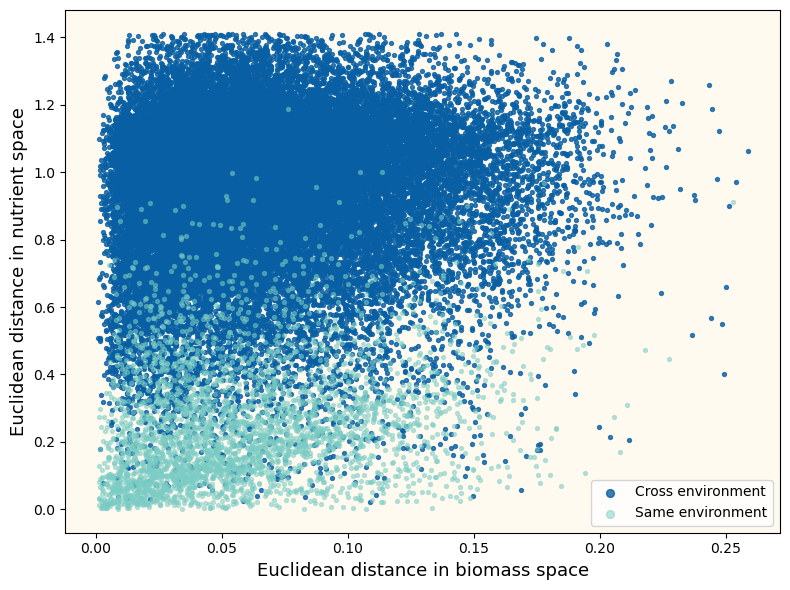

In [20]:
# ================================================================
# PER-SAMPLE DISTANCE-DISTANCE PLOT
# ================================================================
labels = target_trans['source'].values

# ---- compute pairwise distances ----
DX = pairwise_distances(X, metric="euclidean")
DY = pairwise_distances(Y, metric="euclidean")

# ---- upper triangle ----
i, j = np.triu_indices_from(DX, k=1)
dx = DX[i, j]
dy = DY[i, j]
same = labels[i] == labels[j]

# ---- subsample ----
max_pairs = 40000
if len(dx) > max_pairs:
    idx = np.random.choice(len(dx), size=max_pairs, replace=False)
    dx = dx[idx]
    dy = dy[idx]
    same = same[idx]

# ---- plot ----
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(dx[~same], dy[~same], s=8, alpha=0.8, label="Cross environment", color=color_map(0.9))
ax.scatter(dx[same],  dy[same],  s=8, alpha=0.5, label="Same environment", color=color_map(0.5))
# ax.scatter(dx[same],  dy[same],  s=8, alpha=0.3, label="Same environment", color='red')
ax.legend(markerscale=2)
ax.set_xlabel("Euclidean distance in biomass space", fontsize=13)
ax.set_ylabel("Euclidean distance in nutrient space", fontsize=13)
# ax.set_title("Pairwise distances in biomass vs nutrient Space", fontsize=17)
ax.set_facecolor('floralwhite')
plt.tight_layout()
plt.show()

### Heatmap

**Centroids**

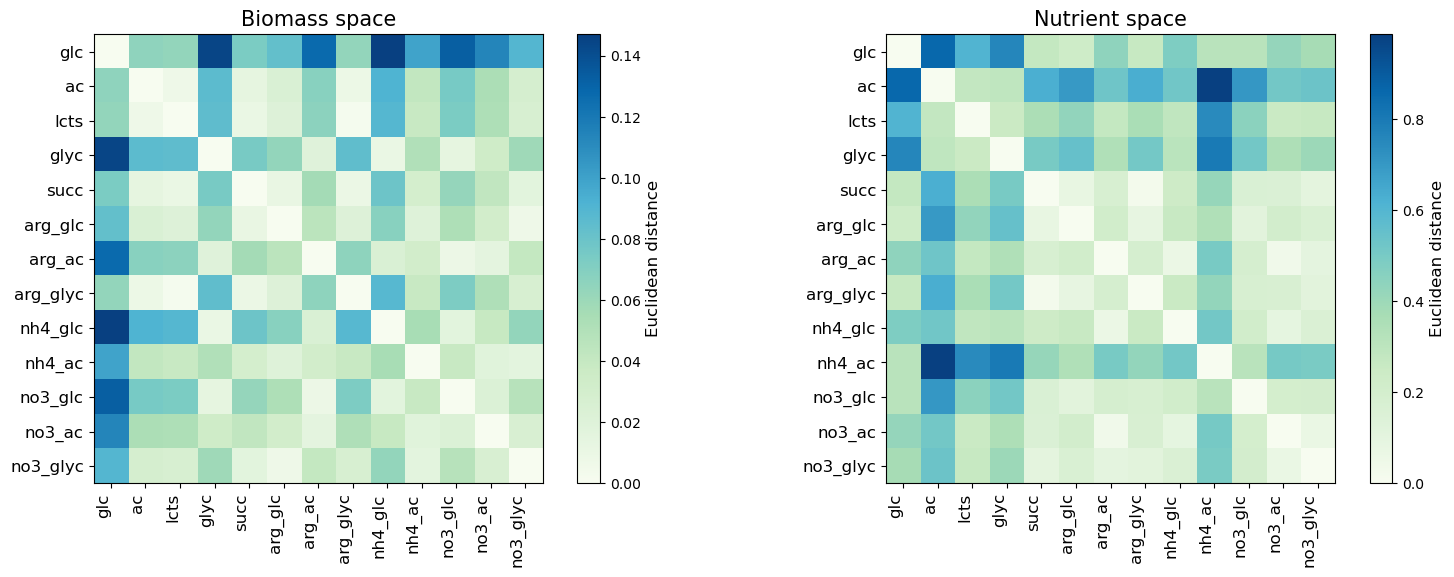

In [38]:
# ================================================================
# CENTROID DISTANCE HEATMAPS (biomass space vs nutrient space)
# ================================================================
labels = target_trans['source'].values

# ---- compute centroids ----
unique_envs = np.unique(labels)
X_centroids = np.array([X[labels == env].mean(axis=0) for env in unique_envs])
Y_centroids = np.array([Y[labels == env].mean(axis=0) for env in unique_envs])

# ---- define custom ordering ----
env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg_glc', 'arg_ac', 'arg_glyc',
             'nh4_glc', 'nh4_ac', 'no3_glc', 'no3_ac', 'no3_glyc']
order_idx = [list(unique_envs).index(env) for env in env_order]

DX_ordered = DX[np.ix_(order_idx, order_idx)]
DY_ordered = DY[np.ix_(order_idx, order_idx)]

# ---- plot side by side ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, D, title in zip(axes, [DX_ordered, DY_ordered], ["Biomass space", "Nutrient space"]):
    im = ax.imshow(D, cmap="GnBu")
    ax.set_xticks(range(len(env_order)))
    ax.set_yticks(range(len(env_order)))
    ax.set_xticklabels(env_order, rotation=90, ha="right", fontsize=12)
    ax.set_yticklabels(env_order, fontsize=12)
    ax.set_title(f"{title}", fontsize=15)
    # plt.colorbar(im, ax=ax)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Euclidean distance", fontsize=12)


# plt.suptitle('Centroid distances between environments', fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [54]:
import matplotlib as mpl

biomass_cmap = mpl.colormaps["YlGnBu"]
biomass_cmap = mpl.colors.LinearSegmentedColormap.from_list(
    "YlGnBu_trunc", biomass_cmap(np.linspace(0.0, 0.29, 256))
)

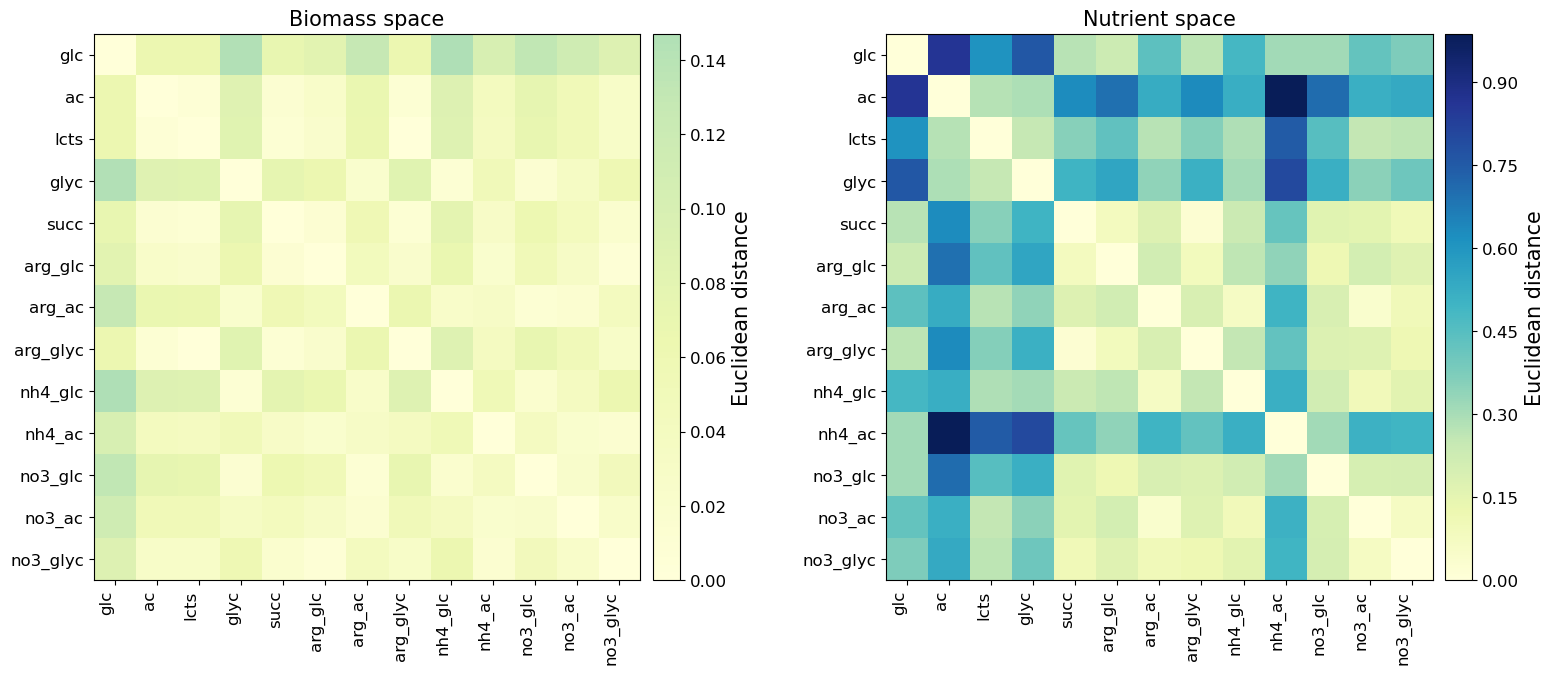

In [64]:
cmaps = [biomass_cmap, "YlGnBu"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, D, title, cmap in zip(axes, [DX_ordered, DY_ordered], ["Biomass space", "Nutrient space"], cmaps):
    im = ax.imshow(D, cmap=cmap)
    ax.set_xticks(range(len(env_order)))
    ax.set_yticks(range(len(env_order)))
    ax.set_xticklabels(env_order, rotation=90, ha="right", fontsize=12)
    ax.set_yticklabels(env_order, fontsize=12)
    ax.set_title(title, fontsize=15)

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
    cbar.set_label("Euclidean distance", fontsize=15)
    cbar.ax.tick_params(labelsize=12)

cbar.set_ticks(np.arange(0, DY_ordered.max(), 0.15))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

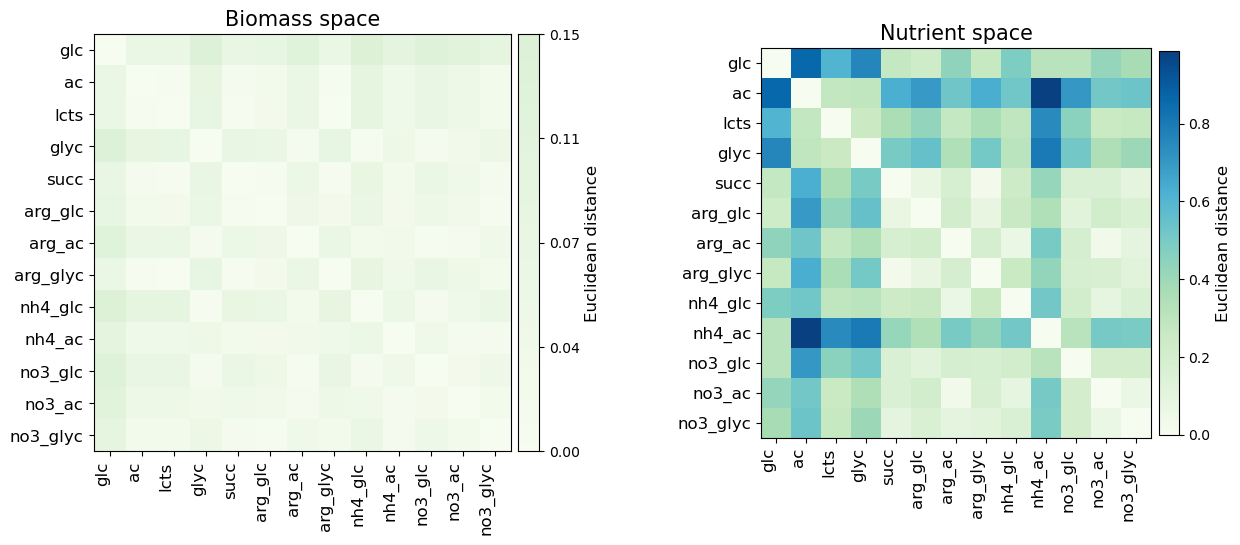

In [37]:
vmin = 0
vmax = max(DX_ordered.max(), DY_ordered.max())
vmax_biomass = DX_ordered.max()

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, D, title in zip(axes, [DX_ordered, DY_ordered], ["Biomass space", "Nutrient space"]):
    im = ax.imshow(D, cmap="GnBu", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(env_order)))
    ax.set_yticks(range(len(env_order)))
    ax.set_xticklabels(env_order, rotation=90, ha="right", fontsize=12)
    ax.set_yticklabels(env_order, fontsize=12)
    ax.set_title(title, fontsize=15)

    if title == "Nutrient space":
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.02)
        cbar.set_label("Euclidean distance", fontsize=12)

fig.subplots_adjust(wspace=0.6)
fig.canvas.draw()  # settle layout before reading positions

biomass_pos = axes[0].get_position()
zoom_ax = fig.add_axes([
    biomass_pos.x1 + 0.005,
    biomass_pos.y0,
    0.015,
    biomass_pos.height
])

gradient = np.linspace(vmin, vmax, 256).reshape(256, 1)
zoom_ax.imshow(gradient[::-1], aspect="auto", cmap="GnBu", vmin=vmin, vmax=vmax)

frac = vmax_biomass / vmax
zoom_ax.set_ylim(255, 255 * (1 - frac))

zoom_ax.set_xticks([])
zoom_ax.yaxis.tick_right()
zoom_ax.yaxis.set_label_position("right")

n_ticks = 5
tick_vals = np.linspace(0, vmax_biomass, n_ticks)
tick_positions = np.linspace(255, 255 * (1 - frac), n_ticks)
zoom_ax.set_yticks(tick_positions)
zoom_ax.set_yticklabels([f"{v:.2f}" for v in tick_vals], fontsize=10)
zoom_ax.set_ylabel("Euclidean distance", fontsize=12)

plt.show()

## Mapping using ML-features